# lda_dcabp_evolution

Evolution of LDA behavioral patterns over time per patient.

1. Load the **day-type sequences** (`embedding_ids`), the trained **LDA model** and the **dictionary**.
2. Attach the clinical dates / event info (`Evento PD`, `Evento PD diff`).
3. Build the **monthly predominant topic** table (30-day blocks).
4. Global plots (from `6_1_entropy_variability_cleaned_dec25.ipynb`):
   - **Predominant topic per month** heatmap (6 topics).
   - **Hypertopic per month** heatmap (favorable vs unfavorable groups).

In [4]:
import ast
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from gensim import corpora
from gensim.models import LdaModel

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Trained LDA artifacts
LDA_MODEL_PATH = PROJECT_ROOT / "models/lda/LDAvis_6topics_100000_180patients_dec25.gensim"
DICTIONARY_PATH = PROJECT_ROOT / "models/lda/dictionary_LDA_180patients_100000.dict"

# eB2 table with day-type sequences (id, embedding_ids) + clinical dates/event
DF_DAY_CSV = PROJECT_ROOT / "data/raw/PD_cutoff_dic_2025s_eB2_Topics_a0_6topics100000.csv"

# Date / event columns to read from DF_DAY_CSV
DATE_COLS = [
    "Fecha_entrada_HDM", "Evento PD", "Tiempo Obs Final",
    "diferencia", "Evento PD diff", "early PD", "primer_registro_EB2",
]

# Reuse the monthly-topics helper from the scripts package
SCRIPTS_LDA = PROJECT_ROOT / "scripts/03_analysis/lda"
if str(SCRIPTS_LDA) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_LDA))

WINDOW_SIZE = 30
MIN_EMBEDDINGS = 15

TABLES_DIR = PROJECT_ROOT / "results/lda/tables"
FIG_DIR = PROJECT_ROOT / "results/lda/figures"

print("Model  :", LDA_MODEL_PATH)
print("Dict   :", DICTIONARY_PATH)
print("eB2 CSV:", DF_DAY_CSV)

Model  : /export/gts_usuarios/lparbaiza/cancer-behavioral-trajectories/models/lda/LDAvis_6topics_100000_180patients_dec25.gensim
Dict   : /export/gts_usuarios/lparbaiza/cancer-behavioral-trajectories/models/lda/dictionary_LDA_180patients_100000.dict
eB2 CSV: /export/gts_usuarios/lparbaiza/cancer-behavioral-trajectories/data/raw/PD_cutoff_dic_2025s_eB2_Topics_a0_6topics100000.csv


## 1 · Load embeddings, LDA model and dictionary

In [5]:
lda_model = LdaModel.load(str(LDA_MODEL_PATH))
dictionary = corpora.Dictionary.load(str(DICTIONARY_PATH))
NUM_TOPICS = lda_model.num_topics
print(f"LDA topics: {NUM_TOPICS} | dictionary size: {len(dictionary)}")

df = pd.read_csv(DF_DAY_CSV)
df = df.rename(columns={"user_id": "id"})
df["embedding_ids"] = df["embedding_ids"].apply(
    lambda v: ast.literal_eval(v) if isinstance(v, str) else v
)
df["id"] = pd.to_numeric(df["id"], errors="coerce").astype("Int64")
print("Patients:", len(df))
df.head()

LDA topics: 6 | dictionary size: 255
Patients: 175


,id,predominant_topic,topic_distribution,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,embedding_ids,Fecha_entrada_HDM,Evento PD,Tiempo Obs Final,diferencia,Evento PD diff,early PD,primer_registro_EB2
0,11001,3,"[0.00019024033, 0.094892785, 0.00019086628, 0....",0.000190,0.094893,0.000191,0.692382,0.017605,0.194739,"[67, 34, 194, 7, 76, 49, 95, 62, 131, 175, 58,...",2023-04-19,0,876,0.0,876.0,0,NaN
1,11003,3,"[0.00047766662, 0.056067478, 0.023019955, 0.67...",0.000478,0.056067,0.023020,0.670386,0.068694,0.181354,"[46, 13, 184, 225, 192, 224, 72, 224, 197, 180...",2023-12-05,1,357,8.0,349.0,0,13/12/23
2,11004,2,"[0.00026418606, 0.12145818, 0.51455325, 0.2545...",0.000264,0.121458,0.514553,0.254527,0.082532,0.026666,"[43, 43, 218, 210, 77, 34, 243, 125, 125, 218,...",2023-12-20,0,631,0.0,631.0,0,NaN
3,11005,1,"[0.031426333, 0.7207797, 0.1621154, 0.00031404...",0.031426,0.720780,0.162115,0.000314,0.000315,0.085049,"[238, 172, 50, 110, 125, 117, 18, 18, 149, 14,...",2024-03-27,0,533,0.0,533.0,0,NaN
4,11006,2,"[0.0005627643, 0.072490364, 0.63257277, 0.0005...",0.000563,0.072490,0.632573,0.000568,0.293243,0.000563,"[247, 69, 91, 142, 125, 208, 208, 15, 247, 51,...",2024-11-20,0,295,0.0,295.0,0,NaN


## 2 · Select day-type sequences + clinical dates / event

`df_day` = (`id`, `embedding_ids`) + the date/event columns read from the eB2 CSV
(`Evento PD`, `Evento PD diff` = time to event in days, etc.).

In [6]:
missing = [c for c in DATE_COLS if c not in df.columns]
if "Evento PD" in missing or "Evento PD diff" in missing:
    raise KeyError(f"eB2 CSV is missing required columns: {missing}")

keep = ["id", "embedding_ids"] + [c for c in DATE_COLS if c in df.columns]
df_day = df[keep].copy()
print("df_day:", df_day.shape)
df_day[["id", "Evento PD", "Evento PD diff"]].head()

df_day: (175, 9)


,id,Evento PD,Evento PD diff
0,11001,0,876.0
1,11003,1,349.0
2,11004,0,631.0
3,11005,0,533.0
4,11006,0,295.0


## 3 · Monthly predominant topic table (30-day blocks)

In [7]:
from monthly_topics_utils import (
    build_monthly_predominant_table,
    sort_patients_for_heatmap,
    topic_month_columns,
)

ordered_df = build_monthly_predominant_table(
    df_day, lda_model, dictionary,
    window_size=WINDOW_SIZE, min_embeddings=MIN_EMBEDDINGS,
)

TABLES_DIR.mkdir(parents=True, exist_ok=True)
monthly_csv = TABLES_DIR / "monthly_predominant_topics.csv"
ordered_df.to_csv(monthly_csv, index=False)
print("Saved:", monthly_csv)
print("Patients in table:", len(ordered_df))
ordered_df.head()

Saved: /export/gts_usuarios/lparbaiza/cancer-behavioral-trajectories/results/lda/tables/monthly_predominant_topics.csv
Patients in table: 172


,id,Event,t_evento_eb2,topic_predominante_mes1,topic_predominante_mes2,topic_predominante_mes3,topic_predominante_mes4,topic_predominante_mes5,topic_predominante_mes6,topic_predominante_mes7,...,topic_predominante_mes23,topic_predominante_mes24,topic_predominante_mes25,topic_predominante_mes26,topic_predominante_mes27,topic_predominante_mes28,topic_predominante_mes29,topic_predominante_mes30,topic_predominante_mes31,topic_predominante_mes32
0,11001,0.0,NaN,3,3,5,5,3,3,5,...,3,3,3,3,3,3,3,3,<NA>,<NA>
1,11004,0.0,NaN,3,2,2,2,2,2,2,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,11005,0.0,NaN,1,1,1,1,1,1,1,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,11006,0.0,NaN,2,2,2,2,2,4,2,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,11007,0.0,NaN,2,2,2,2,2,2,2,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


## 4 · Global plot 1 — Predominant topic per month (6 topics)

/tmp/ipykernel_1552906/3178582236.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({pd.NA: np.nan})


Saved: /export/gts_usuarios/lparbaiza/cancer-behavioral-trajectories/results/lda/figures/predominant_topics_per_month.svg


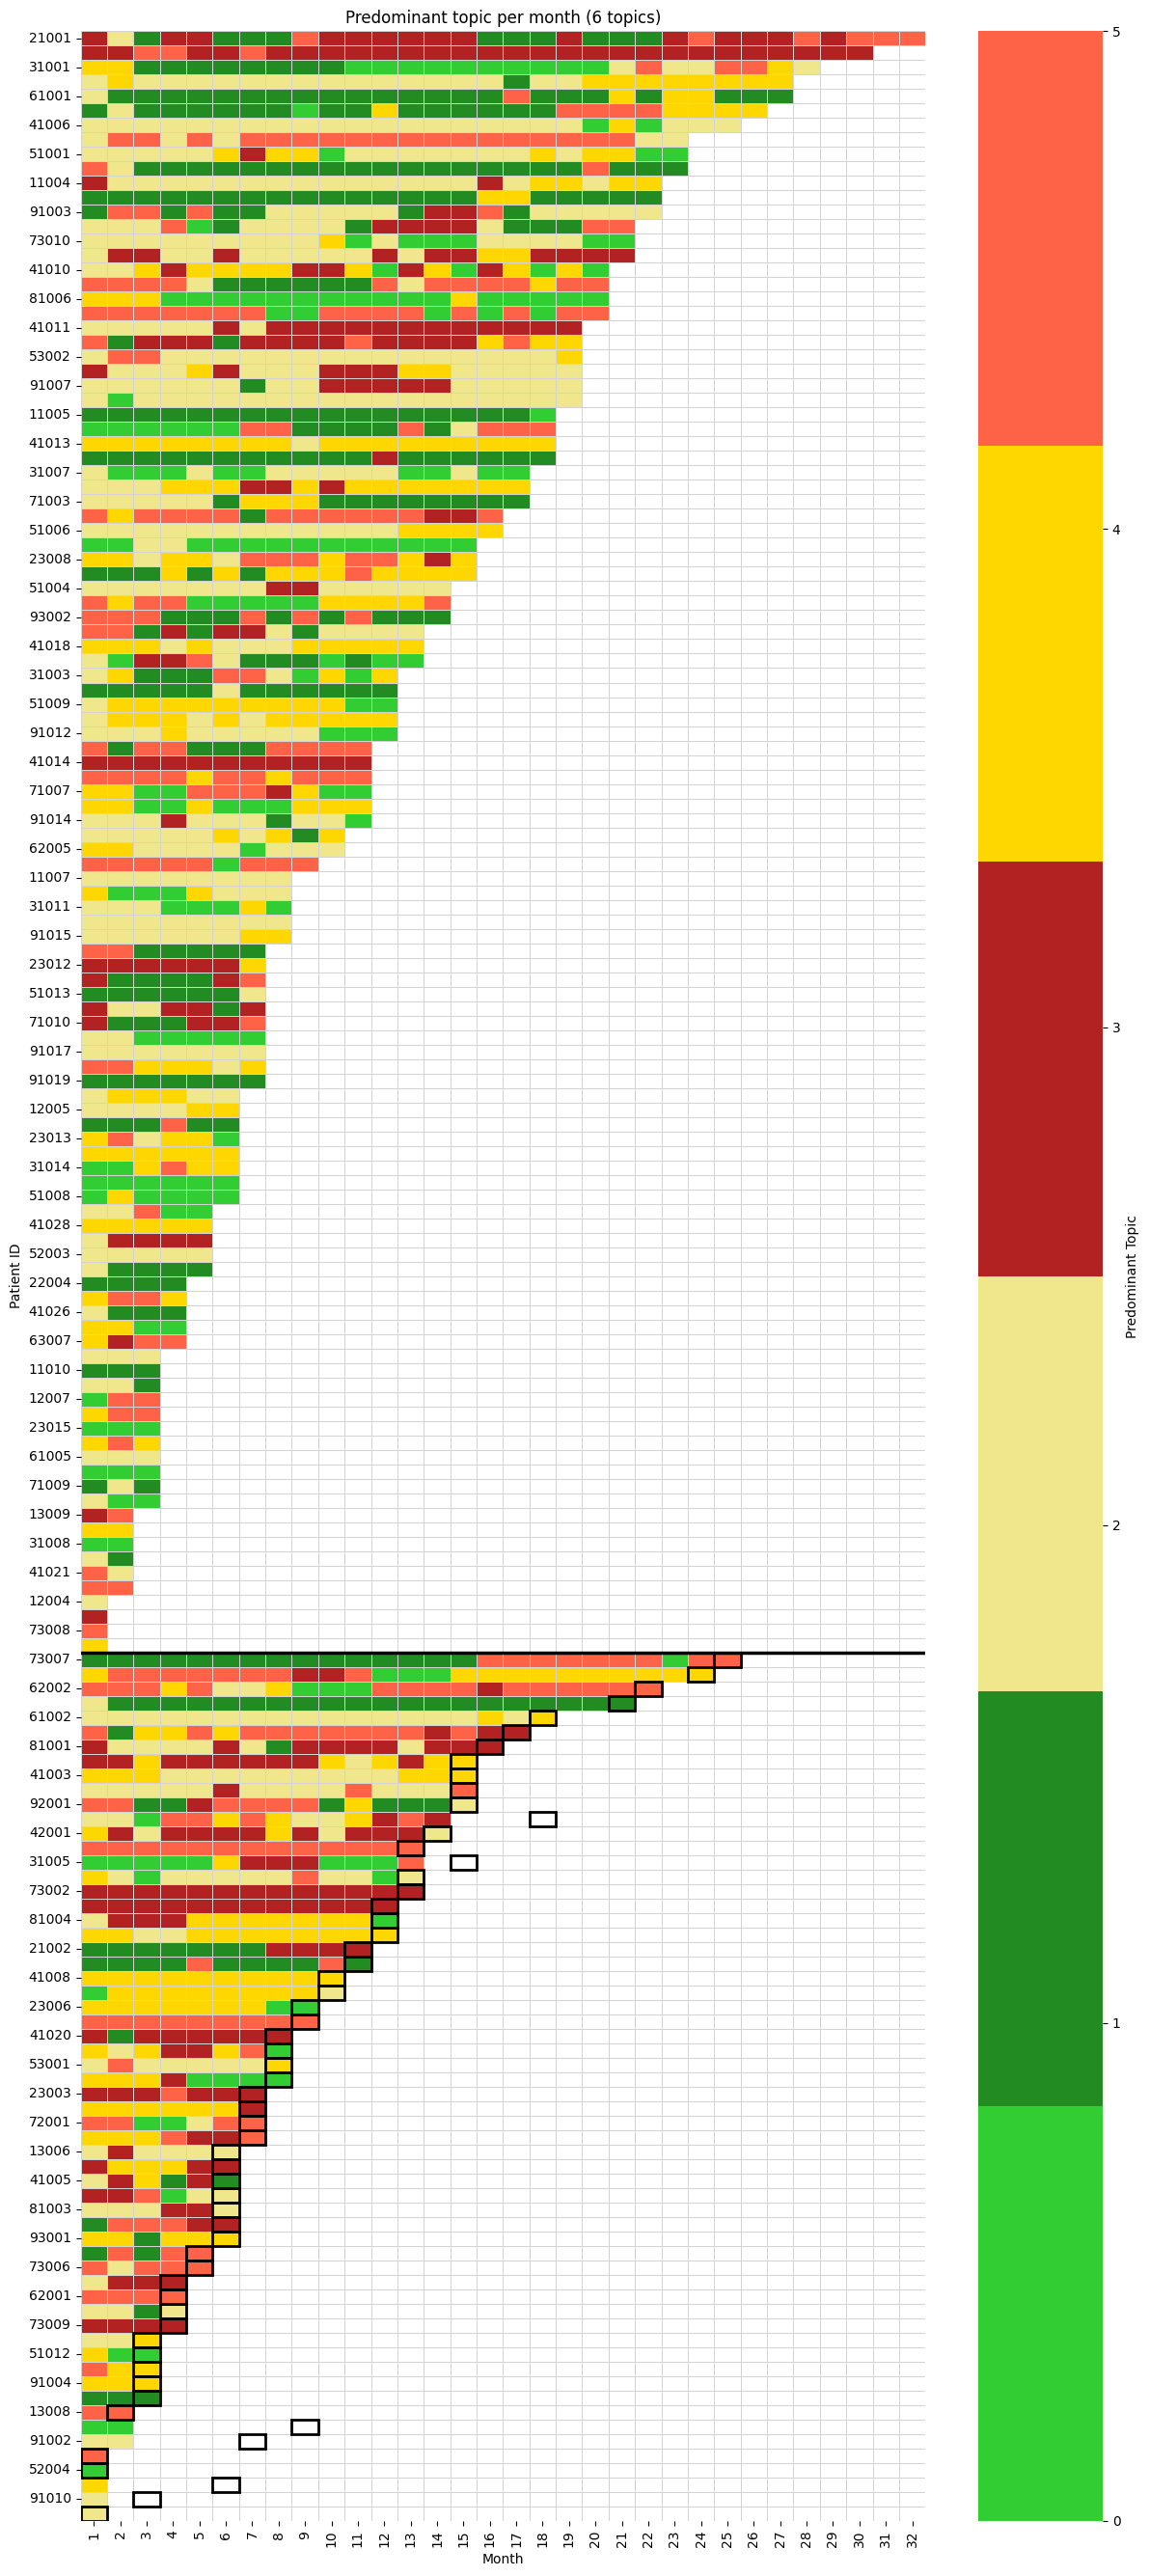

In [8]:
# Discrete colors per topic (notebook 6_1)
HEATMAP_TOPIC_COLORS = {
    0: "#32cd32", 1: "#228b22", 2: "#f0e68c",
    3: "#b22222", 4: "#ffd700", 5: "#ff6347",
}

topic_cols = topic_month_columns(ordered_df)
ordered_sorted = sort_patients_for_heatmap(ordered_df, topic_cols)

plot_df = (
    ordered_sorted[["id"] + topic_cols]
    .set_index("id")
    .replace({pd.NA: np.nan})
    .apply(pd.to_numeric, errors="coerce")
)

color_list = [HEATMAP_TOPIC_COLORS[i] for i in sorted(HEATMAP_TOPIC_COLORS)]
cmap = ListedColormap(color_list)

fig, ax = plt.subplots(figsize=(12, len(plot_df) * 0.15 + 1))
sns.heatmap(
    plot_df, cmap=cmap, vmin=0, vmax=len(color_list) - 1,
    linewidths=0.5, linecolor="lightgray",
    cbar_kws={"label": "Predominant Topic"},
    mask=plot_df.isna(), ax=ax,
)

x_axis = [re.findall(r"\d+", c)[-1] for c in topic_cols]
ax.set_xticklabels(x_axis)

for i, row in ordered_sorted.iterrows():
    if row["Event"] == 1 and not pd.isna(row.get("t_evento_eb2")):
        mes_evento = int(row["t_evento_eb2"] // 30)
        if 0 <= mes_evento < len(topic_cols):
            ax.add_patch(plt.Rectangle((mes_evento, i), 1, 1, fill=False,
                                       edgecolor="black", linewidth=2))

n_no_pd = len(ordered_sorted[ordered_sorted["Event"] == 0])
ax.axhline(n_no_pd, color="black", linewidth=2.5)

ax.set_title(f"Predominant topic per month ({NUM_TOPICS} topics)")
ax.set_xlabel("Month")
ax.set_ylabel("Patient ID")
plt.tight_layout()

FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "predominant_topics_per_month.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "predominant_topics_per_month.svg", bbox_inches="tight")
print("Saved:", FIG_DIR / "predominant_topics_per_month.svg")
plt.show()

## 5 · Global plot 2 — Hypertopic per month (favorable vs unfavorable)

Saved: /export/gts_usuarios/lparbaiza/cancer-behavioral-trajectories/results/lda/figures/hypertopics_per_month.svg


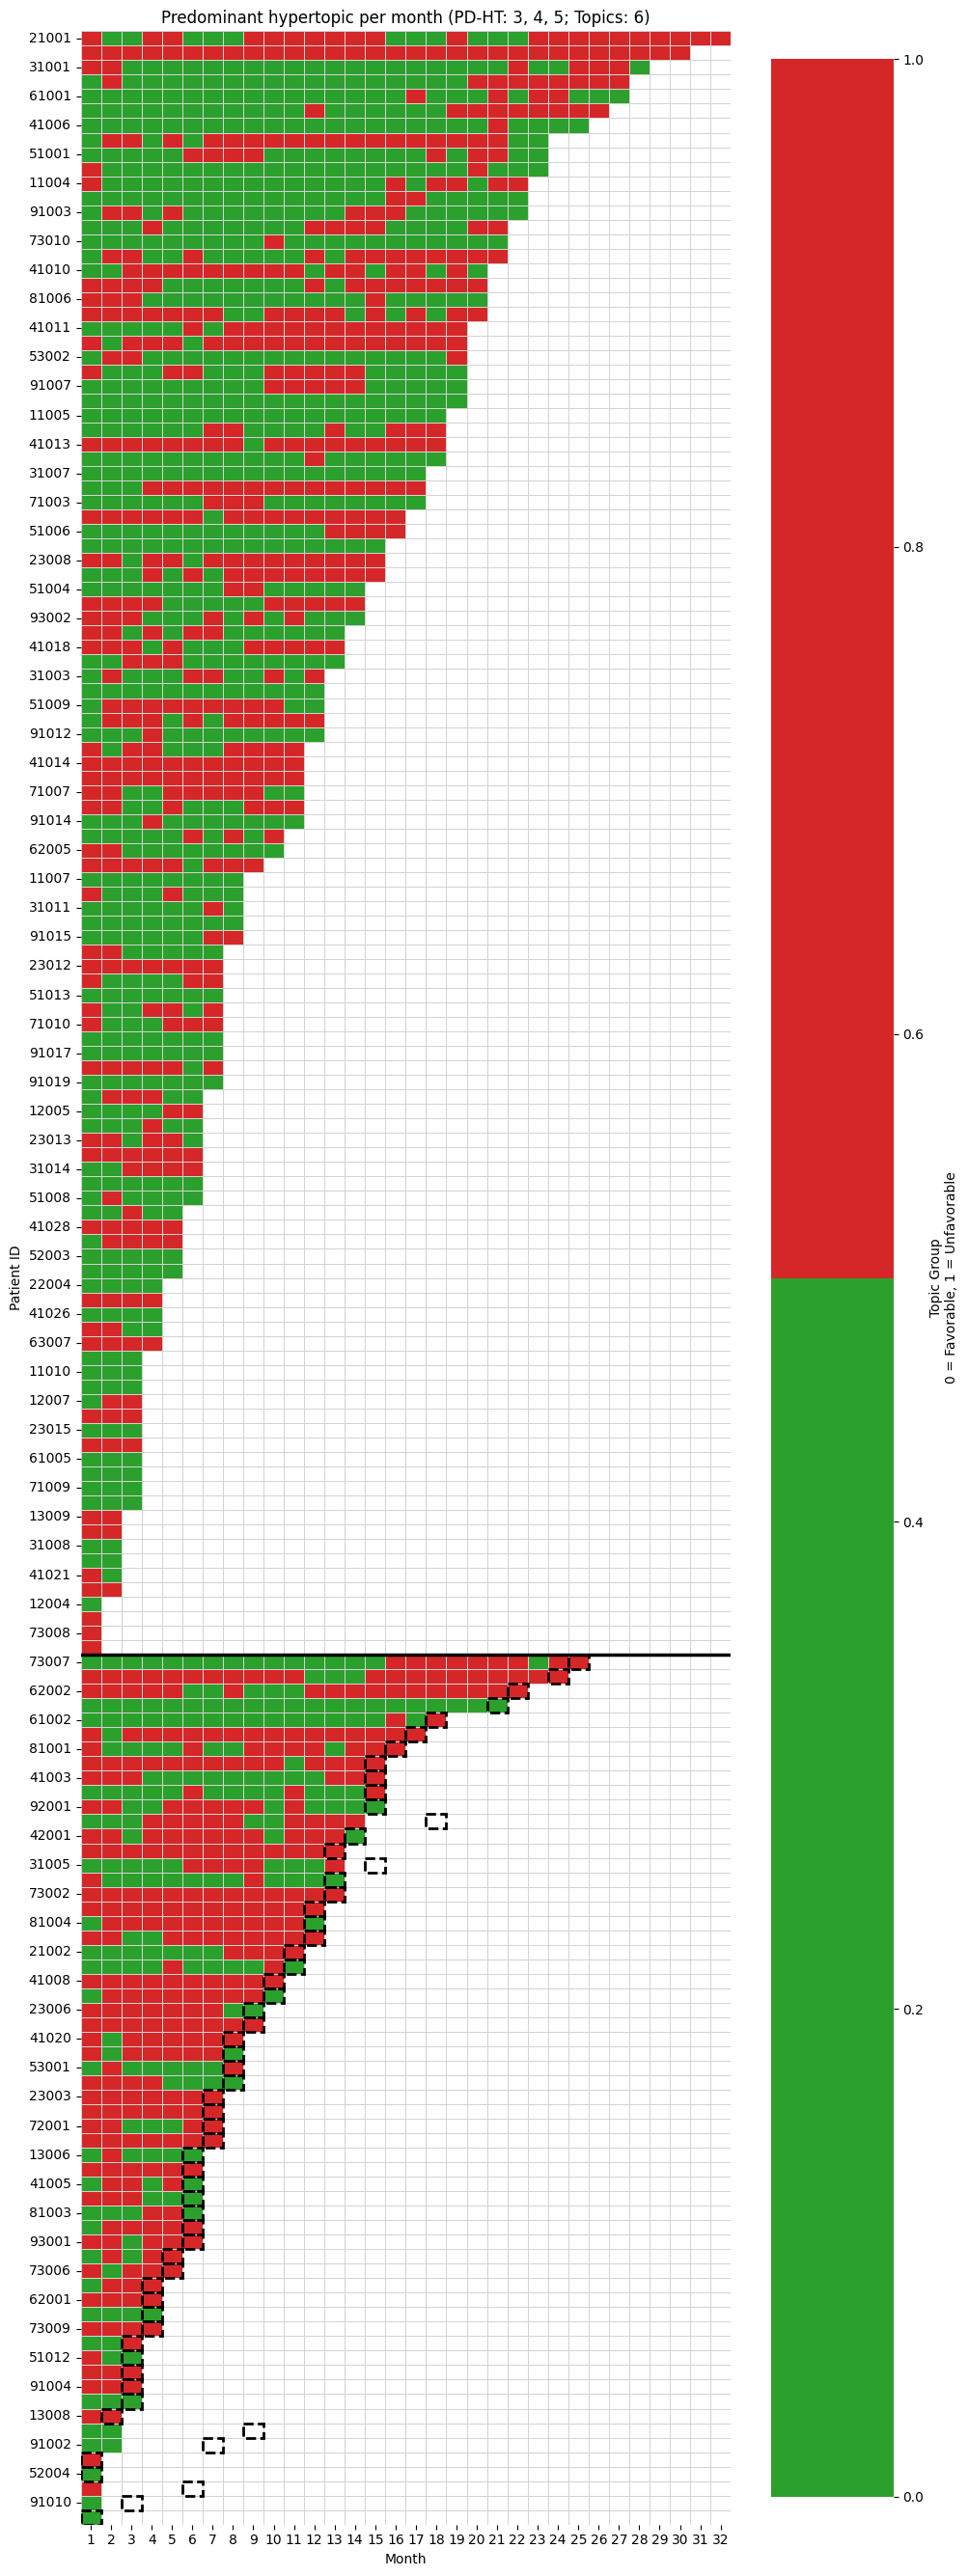

In [9]:
# Collapse the 6 topics into 2 groups (0 = favorable, 1 = unfavorable)
group_map = {0: 0, 1: 0, 2: 0, 3: 1, 4: 1, 5: 1}
plot_df_grouped = plot_df.replace(group_map)

group_colors = ["#2ca02c", "#d62728"]
cmap_groups = ListedColormap(group_colors)

fig, ax = plt.subplots(figsize=(10, len(plot_df_grouped) * 0.15 + 1))
sns.heatmap(
    plot_df_grouped, cmap=cmap_groups, vmin=0, vmax=1,
    linewidths=0.5, linecolor="lightgray",
    mask=plot_df_grouped.isna(),
    xticklabels=x_axis,
    cbar_kws={"label": "Topic Group\n0 = Favorable, 1 = Unfavorable"},
    ax=ax,
)

for i, row in ordered_sorted.iterrows():
    if row["Event"] == 1 and not pd.isna(row.get("t_evento_eb2")):
        mes_evento = int(row["t_evento_eb2"] // 30)
        if 0 <= mes_evento < len(topic_cols):
            ax.add_patch(plt.Rectangle((mes_evento, i), 1, 1, fill=False,
                                       edgecolor="black", linewidth=2, linestyle="--"))

n_no_pd = len(ordered_sorted[ordered_sorted["Event"] == 0])
ax.axhline(n_no_pd, color="black", linewidth=2.5)

ax.set_title(f"Predominant hypertopic per month (PD-HT: 3, 4, 5; Topics: {NUM_TOPICS})")
ax.set_xlabel("Month")
ax.set_ylabel("Patient ID")
plt.tight_layout()

fig.savefig(FIG_DIR / "hypertopics_per_month.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "hypertopics_per_month.svg", bbox_inches="tight")
print("Saved:", FIG_DIR / "hypertopics_per_month.svg")
plt.show()